In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Initialization of Neural Network Parameters


When it comes to deep neural nets, you should be careful about how you initialize the weights. Bad initialization can lead from not learning at all to vanishing/exploding gradients.
Let's demonstrate this with our trivial example.



In [3]:
import jax.numpy as jnp
import jax.random as jrandom

key = jrandom.PRNGKey(0)
key, input_key = jrandom.split(key)

# Generate some synthetic data
N = 1_000
X = jrandom.normal(input_key, (N,))
key, subkey = jrandom.split(key)
y = 1.5 * X ** 2 - 2 * X + jrandom.normal(subkey, (N,)) * 0.5

# Make also a test set (here an ideal one)
N_test = 50
X_test = jnp.linspace(-3, 3, N_test)
key, subkey = jrandom.split(key)
y_test = 1.5 * X_test ** 2 - 2 * X_test + jrandom.normal(subkey, (N_test,)) * 0.5

import numpy as np
shuffle_rng = np.random.default_rng(20260922)
import equinox as eqx
import jax
import optax
from functools import partial

    
# The function below generates batches of data
def data_generator(X, y, batch_size, shuffle=True):
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        shuffle_rng.shuffle(indices)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]

# This is the loss function
def loss(model, x, y):
    y_pred = model(x)
    return optax.l2_loss(y_pred, y).mean()

# This is the training loop
def train_batch(
        model,
        x, y,
        optimizer,
        x_test, y_test,
        n_batch=10,
        n_epochs=10,
        freq=1,
    ):

    # This is the step of the optimizer. We **always** jit:
    @eqx.filter_jit
    def step(opt_state, model, xi, yi):
        value, grads = eqx.filter_value_and_grad(loss)(model, xi, yi)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    # The state of the optimizer
    opt_state = optimizer.init(model)
    # The path of the model
    path = []
    # The path of the test loss
    losses = []
    # The path of the test accuracy
    test_losses = []
    for e in range(n_epochs):
        for i, (xb, yb) in enumerate(data_generator(x, y, n_batch)):
            model, opt_state, value = step(opt_state, model, xb, yb)
            if i % freq == 0:
                path.append(model)
                losses.append(value)
                test_losses.append(loss(model, x_test, y_test))
                print(f"Epoch {e}, step {i}, loss {value:.3f}, test {test_losses[-1]:.3f}")
    return model, path, losses, test_losses

This time we are going to make the model a proper neural network. Let's go with two hidden layers with 10 neurons each. We will use the rectified linear unit (ReLU) activation function for the hidden layers.

In [4]:
class NeuralNetwork(eqx.Module):
    layers: list

    def __init__(self, key):
        key1, key2, key3 = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(1, 10, key=key1),
            eqx.nn.Linear(10, 10, key=key2),
            eqx.nn.Linear(10, 1, key=key3)
        ]
    
    @partial(jax.vmap, in_axes=(None, 0))
    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = jax.nn.relu(layer(x))
        return self.layers[-1](x)

The layers above use Equinox's default initialization. We will compare explicit Xavier and He scalings below.
First, let's examine a poor initialization.
First, set all the weights and biases to the same number, say zero.
Recall that JAX models are immutable, so we need to create a new model.

In [5]:
key, subkey = jrandom.split(key)

model = NeuralNetwork(subkey)

# Set all weights and biases to zero
zero_model = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), model)

# Confirm that everything is set to zero
jax.tree_util.tree_leaves(zero_model)

[Array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 Array([0.], dtype=float32)]

Let's now demonstrate that this model cannot learn because most of the gradients are zero:

In [6]:
from jax import jit, grad

grad_loss = jit(grad(loss))

g = grad_loss(zero_model, X[:, None], y[:, None])

jax.tree_util.tree_leaves(g)

[Array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 Array([-1.7226758], dtype=float32)]

Why does this happen? The reason is the ReLU function. Recall that ReLU is defined as:

$$
\text{relu}(x) = \max(0, x)
$$

So, if the input is negative, the gradient is zero. This is called the dying ReLU problem. If the input is negative, the gradient is zero and the weights are not updated. This is why the model cannot learn.

The same thing happens in other activation functions if we are not careful. For example, in sigmoid, if the input is too large or too small, the gradient is also zero. We say that the gradients are saturated.

Okay, let's shift all weights and biases by a bit so that ReLU is not saturated anymore.
We can achieve this by adding a small number, say 0.1, to everything:

In [7]:
new_model = jax.tree_util.tree_map(lambda x: 0.1 * jnp.ones_like(x), model)
jax.tree_util.tree_leaves(new_model)

[Array([[0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1],
        [0.1]], dtype=float32),
 Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=float32),
 Array([[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]], dtype=float32),
 Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=float32),
 Array([[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]], dtype

Let's see what the gradients are now:

In [8]:
g = grad_loss(new_model, X[:, None], y[:, None])

jax.tree_util.tree_leaves(g)

[Array([[0.01744955],
        [0.01744955],
        [0.01744955],
        [0.01744955],
        [0.01744955],
        [0.01744955],
        [0.01744955],
        [0.01744955],
        [0.01744955],
        [0.01744955]], dtype=float32),
 Array([-0.01413278, -0.01413278, -0.01413278, -0.01413278, -0.01413278,
        -0.01413278, -0.01413278, -0.01413278, -0.01413278, -0.01413278],      dtype=float32),
 Array([[0.00033168, 0.00033168, 0.00033168, 0.00033168, 0.00033168,
         0.00033168, 0.00033168, 0.00033168, 0.00033168, 0.00033168],
        [0.00033168, 0.00033168, 0.00033168, 0.00033168, 0.00033168,
         0.00033168, 0.00033168, 0.00033168, 0.00033168, 0.00033168],
        [0.00033168, 0.00033168, 0.00033168, 0.00033168, 0.00033168,
         0.00033168, 0.00033168, 0.00033168, 0.00033168, 0.00033168],
        [0.00033168, 0.00033168, 0.00033168, 0.00033168, 0.00033168,
         0.00033168, 0.00033168, 0.00033168, 0.00033168, 0.00033168],
        [0.00033168, 0.00033168, 0.0003

Now get non-zero gradients, but we have another problem.
Pay attention to the gradients for the weight of a given layer. They are all the same!
This is not good. The model will move all the weights in the same direction, which is not what we want.
It will never learn anything useful.
This is called the symmetry problem.
We need to initialize the parameters in a way that breaks the symmetry.

## Xavier or Glorot initialization

The Xavier (or Glorot) initialization was introduced by {cite:t}`glorot2010understanding`.
The method initializes the weights of a layer with a uniform distribution in the range $[-a, a]$ with $a$ being:

$$
a = \sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}
$$

where $n_{\text{in}}$ is the number of inputs to the layer and $n_{\text{out}}$ is the number of outputs from the layer.
The weights are initialized by:

$$
w_{ij} \sim \mathcal{U}([-a, a]).
$$

The biases are initialized to zero or to a small positive number (if the activation function is ReLU).

Here is how we can do this in JAX:

In [9]:
def random_weight(key, shape, lim):
    return jrandom.uniform(key, shape, minval=-lim, maxval=lim)


xavier_model = model
for i in range(3):
    # Initialize the weight for layer i
    key, subkey = jrandom.split(key)
    shape = xavier_model.layers[i].weight.shape
    xavier_model = eqx.tree_at(
        lambda m: m.layers[i].weight,
        xavier_model,
        random_weight(
            subkey,
            shape,
            jnp.sqrt(6 / (shape[0] + shape[1]))
        ),
    )
    # Set the bias to 0.1
    xavier_model = eqx.tree_at(
        lambda m: m.layers[i].bias,
        xavier_model,
        0.1 * jnp.ones_like(xavier_model.layers[i].bias),
    )

jax.tree_util.tree_leaves(xavier_model)

[Array([[-0.50944334],
        [ 0.6555031 ],
        [-0.00895034],
        [-0.43670258],
        [ 0.29304954],
        [-0.68030745],
        [-0.38249925],
        [ 0.14994344],
        [ 0.00321881],
        [-0.50308985]], dtype=float32),
 Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], dtype=float32),
 Array([[-0.08604445,  0.31424475, -0.426348  , -0.37588376,  0.3140371 ,
         -0.1688331 ,  0.09420159,  0.43502867, -0.34132618, -0.29280296],
        [ 0.00367303,  0.12309872, -0.5208639 ,  0.42356023, -0.3674819 ,
         -0.4593453 , -0.42880788,  0.04735576, -0.25516003,  0.23702262],
        [ 0.19250754, -0.21789095, -0.01405981, -0.5397804 ,  0.068449  ,
         -0.5366325 , -0.47889748, -0.39644158, -0.2567417 ,  0.30210117],
        [-0.25991392, -0.46714136,  0.03298216, -0.463268  , -0.5052308 ,
          0.27617347,  0.19386812, -0.08710835,  0.19945842, -0.492708  ],
        [ 0.35155037,  0.48413482,  0.11518526,  0.19391042,  0.47680247,
        

Test the gradients:

In [10]:
g = grad_loss(xavier_model, X[:, None], y[:, None])

jax.tree_util.tree_leaves(g)

[Array([[-0.09432621],
        [ 0.3311274 ],
        [-0.62047035],
        [-0.74014306],
        [ 0.5136982 ],
        [-1.0011775 ],
        [ 0.16015121],
        [ 0.1695435 ],
        [-0.33279976],
        [ 0.76980144]], dtype=float32),
 Array([ 0.05651332,  0.19020745,  0.30523688,  0.51873463,  0.3130104 ,
         0.69955516, -0.11339553,  0.22268894,  0.5663036 , -0.54094684],      dtype=float32),
 Array([[ 3.25234898e-04,  8.45430866e-02,  5.32228826e-03,
          3.36534344e-04,  4.13288102e-02,  3.01692227e-04,
          3.41541483e-04,  2.42667142e-02,  6.77317474e-03,
          3.26412817e-04],
        [ 3.33994649e-05,  2.57810345e-04,  1.29812543e-04,
          4.74119734e-05,  1.87988669e-04,  6.90358684e-06,
          5.78534891e-05,  1.60421245e-04,  1.32156769e-04,
          3.46233792e-05],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000

Another thing that is commonly done is to look at the histogram of the gradient of all parameters:

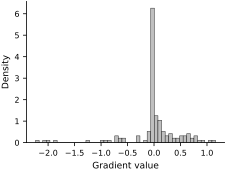

In [11]:
all_grads = jnp.hstack(
    jax.tree_util.tree_map(
        lambda p: p.flatten(),
        jax.tree_util.tree_leaves(g)
    )
)
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.hist(all_grads, bins=50, density=True, color="0.75", edgecolor="black", linewidth=0.4)
ax.set(xlabel="Gradient value", ylabel="Density");

It looks better than before, but it is not perfect.
The reason is that Xavier initialization has been designed for sigmoid and tanh activation functions.
For ReLU, we need to use a different initialization.

## He initialization

The He initialization was introduced by {cite:t}`he2015delving`.
The method initializes the weights of a layer with a uniform distribution in the range $[-a, a]$ with $a$ being:

$$
a = \sqrt{\frac{6}{n_{\text{in}}}}
$$

where $n_{\text{in}}$ is the number of inputs to the layer.
The resulting weight variance is $a^2/3=2/n_{\text{in}}$, the He scaling for a ReLU layer. This differs from the default scaling in `equinox.nn.Linear`.
We apply it explicitly to the two hidden layers. The scalar output layer has no ReLU, so we keep its Xavier weights. Biases remain at 0.1 in both comparisons.

In [12]:
he_model = xavier_model
for i in range(len(he_model.layers) - 1):
    key, subkey = jrandom.split(key)
    shape = he_model.layers[i].weight.shape
    he_model = eqx.tree_at(
        lambda m: m.layers[i].weight,
        he_model,
        random_weight(subkey, shape, jnp.sqrt(6 / shape[1])),
    )

g = grad_loss(he_model, X[:, None], y[:, None])
jax.tree_util.tree_leaves(g)

[Array([[-1.7483829 ],
        [-0.09297272],
        [-0.3639858 ],
        [ 1.2010206 ],
        [ 1.4579656 ],
        [-0.7270551 ],
        [-0.420414  ],
        [ 0.7893204 ],
        [-1.2079097 ],
        [ 0.8756445 ]], dtype=float32),
 Array([ 1.2582616 , -0.05648929, -0.24988388,  0.8185597 , -1.0657248 ,
         0.63848895,  0.3128867 ,  0.5212817 ,  0.86819905,  0.5808441 ],      dtype=float32),
 Array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00],
        [ 2.5375388e-03,  1.6059752e+00,  7.6550478e-01,  1.3673499e+00,
          2.5043450e-03,  5.8517158e-03,  3.1409094e-03,  2.2433267e+00,
          2.9869687e-03,  1.5805918e+00],
        [ 1.7508921e-03,  3.7416364e-03,  2.2506623e-03,  3.3016263e-03,
          1.7077397e-03,  1.2729429e-03,  2.5211344e-03,  4.9282755e-03,
          2.3270564e-03,  3.6945287e-03],
        [ 6.2087172e-

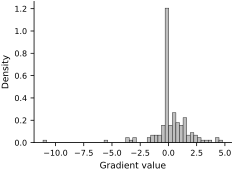

In [13]:
all_grads = jnp.hstack(
    jax.tree_util.tree_map(
        lambda p: p.flatten(),
        jax.tree_util.tree_leaves(g)
    )
)
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.hist(all_grads, bins=50, density=True, color="0.75", edgecolor="black", linewidth=0.4)
ax.set(xlabel="Gradient value", ylabel="Density");

The histogram shows the gradient scales for this particular initialization. A wider histogram alone does not establish that an initialization is better.

You should use He initialization for ReLU and Xavier initialization for sigmoid and tanh.
You should prefer He initialization for deeper networks.
But at the end of the day, these are just rules of thumb.
You should always look at your gradient histograms and make sure that they are not too peaked at zero.

Let's finish up by seeing how our network can learn:

In [14]:
model, path, losses, test_losses = train_batch(
    he_model,
    X[:, None], y[:, None],
    optax.adam(0.01),
    X_test[:, None], y_test[:, None],
    n_batch=100,
    n_epochs=100,
    freq=10,
)

Epoch 0, step 0, loss 16.327, test 46.284
Epoch 1, step 0, loss 6.297, test 28.578
Epoch 2, step 0, loss 5.330, test 24.556
Epoch 3, step 0, loss 6.079, test 24.373
Epoch 4, step 0, loss 8.699, test 24.041
Epoch 5, step 0, loss 5.018, test 23.250
Epoch 6, step 0, loss 2.319, test 23.119
Epoch 7, step 0, loss 3.676, test 22.484
Epoch 8, step 0, loss 2.885, test 22.173
Epoch 9, step 0, loss 3.673, test 21.480
Epoch 10, step 0, loss 3.460, test 21.137
Epoch 11, step 0, loss 2.981, test 20.701
Epoch 12, step 0, loss 2.744, test 20.370
Epoch 13, step 0, loss 3.614, test 19.969
Epoch 14, step 0, loss 7.517, test 19.680
Epoch 15, step 0, loss 3.369, test 19.298
Epoch 16, step 0, loss 1.734, test 19.199


Epoch 17, step 0, loss 5.661, test 18.709
Epoch 18, step 0, loss 3.771, test 18.466
Epoch 19, step 0, loss 4.875, test 18.243
Epoch 20, step 0, loss 4.082, test 17.935
Epoch 21, step 0, loss 4.604, test 17.693
Epoch 22, step 0, loss 2.603, test 17.528
Epoch 23, step 0, loss 1.150, test 17.214
Epoch 24, step 0, loss 3.165, test 17.030
Epoch 25, step 0, loss 5.092, test 16.753
Epoch 26, step 0, loss 4.524, test 16.533
Epoch 27, step 0, loss 4.682, test 16.363
Epoch 28, step 0, loss 3.009, test 16.104
Epoch 29, step 0, loss 2.432, test 15.917
Epoch 30, step 0, loss 1.914, test 15.698
Epoch 31, step 0, loss 1.044, test 15.515
Epoch 32, step 0, loss 1.648, test 15.321
Epoch 33, step 0, loss 1.212, test 15.127


Epoch 34, step 0, loss 1.789, test 14.938
Epoch 35, step 0, loss 2.454, test 14.760
Epoch 36, step 0, loss 1.786, test 14.581
Epoch 37, step 0, loss 3.141, test 14.407
Epoch 38, step 0, loss 3.843, test 14.243
Epoch 39, step 0, loss 2.713, test 14.083
Epoch 40, step 0, loss 1.496, test 13.924
Epoch 41, step 0, loss 0.750, test 13.746
Epoch 42, step 0, loss 3.934, test 13.590
Epoch 43, step 0, loss 2.552, test 13.435
Epoch 44, step 0, loss 2.059, test 13.286


Epoch 45, step 0, loss 0.825, test 13.156
Epoch 46, step 0, loss 1.478, test 13.006
Epoch 47, step 0, loss 2.765, test 12.841
Epoch 48, step 0, loss 1.837, test 12.696
Epoch 49, step 0, loss 0.914, test 12.621
Epoch 50, step 0, loss 1.600, test 12.423
Epoch 51, step 0, loss 1.107, test 12.298
Epoch 52, step 0, loss 2.170, test 12.162
Epoch 53, step 0, loss 2.512, test 12.024
Epoch 54, step 0, loss 3.625, test 11.891
Epoch 55, step 0, loss 1.878, test 11.769


Epoch 56, step 0, loss 0.756, test 11.651
Epoch 57, step 0, loss 0.397, test 11.539
Epoch 58, step 0, loss 2.512, test 11.430
Epoch 59, step 0, loss 0.761, test 11.300
Epoch 60, step 0, loss 1.327, test 11.162
Epoch 61, step 0, loss 2.130, test 11.054
Epoch 62, step 0, loss 2.058, test 10.949
Epoch 63, step 0, loss 1.717, test 10.835
Epoch 64, step 0, loss 1.831, test 10.719
Epoch 65, step 0, loss 1.602, test 10.616


Epoch 66, step 0, loss 1.288, test 10.514
Epoch 67, step 0, loss 0.842, test 10.411
Epoch 68, step 0, loss 0.553, test 10.309
Epoch 69, step 0, loss 0.711, test 10.200
Epoch 70, step 0, loss 2.102, test 10.105
Epoch 71, step 0, loss 0.485, test 10.007
Epoch 72, step 0, loss 0.776, test 9.915


Epoch 73, step 0, loss 1.687, test 9.858
Epoch 74, step 0, loss 1.960, test 9.718
Epoch 75, step 0, loss 1.447, test 9.633
Epoch 76, step 0, loss 1.116, test 9.549
Epoch 77, step 0, loss 0.955, test 9.463
Epoch 78, step 0, loss 0.966, test 9.373
Epoch 79, step 0, loss 0.504, test 9.308
Epoch 80, step 0, loss 0.729, test 9.217
Epoch 81, step 0, loss 1.044, test 9.119
Epoch 82, step 0, loss 1.372, test 9.039
Epoch 83, step 0, loss 0.810, test 8.954
Epoch 84, step 0, loss 1.030, test 8.878
Epoch 85, step 0, loss 0.925, test 8.802


Epoch 86, step 0, loss 1.123, test 8.719
Epoch 87, step 0, loss 1.673, test 8.645
Epoch 88, step 0, loss 1.058, test 8.574
Epoch 89, step 0, loss 1.314, test 8.488
Epoch 90, step 0, loss 1.008, test 8.436
Epoch 91, step 0, loss 0.611, test 8.369


Epoch 92, step 0, loss 1.173, test 8.293
Epoch 93, step 0, loss 0.916, test 8.209
Epoch 94, step 0, loss 1.090, test 8.148
Epoch 95, step 0, loss 1.180, test 8.088
Epoch 96, step 0, loss 0.432, test 8.009
Epoch 97, step 0, loss 1.932, test 7.949
Epoch 98, step 0, loss 0.409, test 7.875
Epoch 99, step 0, loss 0.871, test 7.808


Here is the evolution of the loss:

array([<Axes: title={'center': 'Loss'}, xlabel='Update $\\times$ 10', ylabel='Loss'>],
      dtype=object)

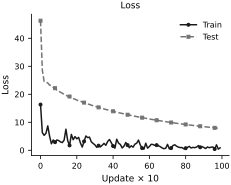

In [15]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
markevery = max(1, len(losses) // 12)
ax.plot(losses, color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label="Train")
ax.plot(test_losses, color="0.45", linestyle="--", marker="s", markevery=markevery, markersize=3, label="Test")
ax.set(xlabel="Update $\\times$ 10", ylabel="Loss", title="Loss")
plt.legend(loc='best', frameon=False)
finalize_axes(keep_box=False)

Let's make some predictions:

array([<Axes: title={'center': 'Model fit'}, xlabel='x', ylabel='y'>],
      dtype=object)

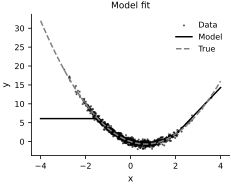

In [16]:
xs = jnp.linspace(-4, 4, 100)
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.scatter(X, y, color='black', label="Data", alpha=0.5, s=2)
ax.plot(xs, model(xs[:, None]).flatten(), color="black", label="Model")
ax.plot(xs, 1.5 * xs ** 2 - 2 * xs, '--', color="0.5", label="True")
ax.set(xlabel="x", ylabel="y", title="Model fit")
plt.legend(loc='best', frameon=False)
finalize_axes(keep_box=False)

The network fits the central part of the data but misses the negative tail in this run. He initialization controls the initial weight variance; it does not guarantee that all ReLU units remain active or that the trained model fits well. The held-out predictions still need checking. For this quadratic data-generating model, polynomial regression would be a simpler choice.